# BMRCL Next-Hour Demand Prediction — Baselines & ML

This notebook begins the forecasting experiments for:

\[
\hat D_{s,t+1}=f(X_{s,t})
\]

where \(D_{s,t+1}\) is passenger boarding demand at station \(s\) during the next hour.

## Experiments
1. Naive baselines
2. Ridge Regression
3. Random Forest
4. XGBoost
5. XGBoost feature-group ablation
6. Validation-only hyperparameter selection
7. Final test evaluation
8. Error analysis and feature importance

The test set is never used for model selection.


In [25]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("Install XGBoost first: pip install xgboost")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Academic-paper plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})


In [3]:
candidates = [
    Path("processed_modeling") / "bmrcl_modeling_master.csv",
    Path("../processed_modeling") / "bmrcl_modeling_master.csv",
    Path("/mnt/data/BMRCL_Data/processed_modeling/bmrcl_modeling_master.csv"),
]
MASTER_PATH = next((p for p in candidates if p.exists()), None)

if MASTER_PATH is None:
    raise FileNotFoundError(
        "Run BMRCL_Modeling_Dataset_and_Split.ipynb first; "
        "bmrcl_modeling_master.csv was not found."
    )

PROJECT_ROOT = MASTER_PATH.parent.parent
RESULTS_DIR = PROJECT_ROOT / "model_results"
FIGURES_DIR = PROJECT_ROOT / "figures_modeling"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(MASTER_PATH, parse_dates=["datetime", "Date"])
df["demand_current"] = df["demand"]

print("Loaded:", MASTER_PATH)
print("Shape:", df.shape)


Loaded: processed_modeling\bmrcl_modeling_master.csv
Shape: (75696, 40)


## 1. Chronological split and feature groups

In [4]:
TRAIN_END = pd.Timestamp("2025-09-14 23:00:00")
VAL_START = pd.Timestamp("2025-09-15")
VAL_END = pd.Timestamp("2025-09-21 23:00:00")
TEST_START = pd.Timestamp("2025-09-22")
TEST_END = pd.Timestamp("2025-09-30 23:00:00")

df["split"] = np.select(
    [
        df["datetime"] <= TRAIN_END,
        df["datetime"].between(VAL_START, VAL_END),
        df["datetime"].between(TEST_START, TEST_END),
    ],
    ["train", "validation", "test"],
    default="outside",
)

TIME_FEATURES = [
    "station", "Hour", "day_of_week_num", "month_num",
    "hour_sin", "hour_cos"
]

CALENDAR_FEATURES = [
    "is_weekend", "is_public_holiday", "is_major_city_event",
    "is_working_day_proxy", "is_day_before_public_holiday",
    "is_day_after_public_holiday"
]

WEATHER_FEATURES = [
    "temp", "rhum", "prcp", "wspd", "pres", "cldc", "coco"
]

# demand_current is D_t; demand_lag_1h is D_(t-1).
HISTORY_FEATURES = [
    "demand_current", "demand_lag_1h", "demand_lag_2h",
    "demand_lag_3h", "demand_lag_24h", "demand_lag_168h",
    "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_24h"
]

# Corrected parking-column handling.
STATIC_FEATURES = [
    c for c in ["2_WHEELER", "4_WHEELER", "CYCLES", "LCV"]
    if c in df.columns
]

TARGET = "target_next_hour"

FEATURE_SETS = {
    "E1_Time_Station": TIME_FEATURES,
    "E2_Time_Calendar": TIME_FEATURES + CALENDAR_FEATURES,
    "E3_Time_Calendar_Weather": TIME_FEATURES + CALENDAR_FEATURES + WEATHER_FEATURES,
    "E4_Full_Temporal": TIME_FEATURES + CALENDAR_FEATURES + WEATHER_FEATURES + HISTORY_FEATURES,
    "E5_Full_Plus_Parking": TIME_FEATURES + CALENDAR_FEATURES + WEATHER_FEATURES + HISTORY_FEATURES + STATIC_FEATURES,
}

display(df.groupby("split")["datetime"].agg(["min", "max", "count"]))
print("Stations:", df["station"].nunique())
print("Parking features:", STATIC_FEATURES)


,min,max,count
split,,,
test,2025-09-22,2025-09-30 23:00:00,17928
train,2025-08-11,2025-09-14 23:00:00,43824
validation,2025-09-15,2025-09-21 23:00:00,13944


Stations: 83
Parking features: ['2_WHEELER', '4_WHEELER']


## 2. Evaluation metrics

In [26]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.abs(y_true) + np.abs(y_pred)
    num = 2 * np.abs(y_true - y_pred)
    return 100 * np.mean(np.divide(num, den, out=np.zeros_like(num), where=den != 0))

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.sum(np.abs(y_true))
    return np.nan if den == 0 else 100 * np.sum(np.abs(y_true - y_pred)) / den

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "sMAPE_%": smape(y_true, y_pred),
        "WAPE_%": wape(y_true, y_pred),
    }


## 3. Baselines

In [27]:
# Exact historical lookup
lookup = dict(zip(zip(df["station"], df["datetime"]), df["demand"]))

def demand_at(station, ts):
    return lookup.get((station, ts), np.nan)

test = df[df["split"] == "test"].copy()

# Predict D_(t+1) using D_t.
test["last_observed"] = test["demand_current"]

# Predict D_(t+1) using the same hour on the previous day/week.
test["previous_day"] = [
    demand_at(s, t + pd.Timedelta(hours=1) - pd.Timedelta(hours=24))
    for s, t in zip(test["station"], test["datetime"])
]
test["previous_week"] = [
    demand_at(s, t + pd.Timedelta(hours=1) - pd.Timedelta(hours=168))
    for s, t in zip(test["station"], test["datetime"])
]

baseline_rows = []
for name, col in [
    ("Last observed demand", "last_observed"),
    ("Same hour previous day", "previous_day"),
    ("Same hour previous week", "previous_week"),
]:
    valid = test[TARGET].notna() & test[col].notna()
    baseline_rows.append({
        "model": name,
        "n": int(valid.sum()),
        **metrics(test.loc[valid, TARGET], test.loc[valid, col])
    })

baseline_results = pd.DataFrame(baseline_rows).sort_values("MAE")
display(baseline_results)


,model,n,MAE,RMSE,R2,sMAPE_%,WAPE_%
2,Same hour previous week,17845,45.694424,100.446697,0.957992,17.121593,12.308408
1,Same hour previous day,17845,91.721435,224.093647,0.790916,31.226115,24.706402
0,Last observed demand,17845,127.974727,236.976967,0.766184,53.283332,34.471714


## 4. Preprocessing helpers

In [28]:
def split_data(features):
    required = features + [TARGET]
    parts = {}
    for split in ["train", "validation", "test"]:
        part = df[df["split"] == split].dropna(subset=required).copy()
        parts[split] = part
    return parts["train"], parts["validation"], parts["test"]

def preprocessor(features, scale_numeric=False):
    cat = [c for c in features if c == "station"]
    num = [c for c in features if c != "station"]

    transformers = []

    if cat:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
            ]),
            cat
        ))

    if num:
        numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
        if scale_numeric:
            numeric_steps.append(("scaler", StandardScaler()))
        transformers.append(("num", Pipeline(numeric_steps), num))

    return ColumnTransformer(transformers=transformers)

features_e4 = FEATURE_SETS["E4_Full_Temporal"]
train_e4, val_e4, test_e4 = split_data(features_e4)

print("E4 rows:")
print("Train:", len(train_e4))
print("Validation:", len(val_e4))
print("Test:", len(test_e4))


E4 rows:
Train: 15853
Validation: 13944
Test: 17845


## 5. Ridge Regression

In [29]:
ridge = Pipeline([
    ("prep", preprocessor(features_e4, scale_numeric=True)),
    ("model", Ridge(alpha=10.0))
])

ridge.fit(train_e4[features_e4], train_e4[TARGET])

ridge_val = ridge.predict(val_e4[features_e4])
ridge_test = ridge.predict(test_e4[features_e4])

ridge_results = pd.DataFrame([
    {"model": "Ridge", "split": "validation", **metrics(val_e4[TARGET], ridge_val)},
    {"model": "Ridge", "split": "test", **metrics(test_e4[TARGET], ridge_test)},
])

display(ridge_results)


,model,split,MAE,RMSE,R2,sMAPE_%,WAPE_%
0,Ridge,validation,110.860884,187.474491,0.862949,78.014041,30.001385
1,Ridge,test,110.438381,180.394729,0.864509,78.264585,29.748063


## 6. Random Forest

In [30]:
rf = Pipeline([
    ("prep", preprocessor(features_e4)),
    ("model", RandomForestRegressor(
        n_estimators=250,
        max_depth=18,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(train_e4[features_e4], train_e4[TARGET])

rf_val = rf.predict(val_e4[features_e4])
rf_test = rf.predict(test_e4[features_e4])

rf_results = pd.DataFrame([
    {"model": "Random Forest", "split": "validation", **metrics(val_e4[TARGET], rf_val)},
    {"model": "Random Forest", "split": "test", **metrics(test_e4[TARGET], rf_test)},
])

display(rf_results)


,model,split,MAE,RMSE,R2,sMAPE_%,WAPE_%
0,Random Forest,validation,61.271395,124.780913,0.939285,58.973922,16.581382
1,Random Forest,test,59.510094,117.998623,0.942028,57.361808,16.029844


## 7. XGBoost

In [31]:
xgb = Pipeline([
    ("prep", preprocessor(features_e4)),
    ("model", XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb.fit(train_e4[features_e4], train_e4[TARGET])

xgb_val = xgb.predict(val_e4[features_e4])
xgb_test = xgb.predict(test_e4[features_e4])

xgb_results = pd.DataFrame([
    {"model": "XGBoost", "split": "validation", **metrics(val_e4[TARGET], xgb_val)},
    {"model": "XGBoost", "split": "test", **metrics(test_e4[TARGET], xgb_test)},
])

display(xgb_results)


,model,split,MAE,RMSE,R2,sMAPE_%,WAPE_%
0,XGBoost,validation,47.684627,95.036963,0.964781,56.294649,12.904505
1,XGBoost,test,47.356631,92.162105,0.964636,55.313163,12.756145


## 8. Initial model comparison

In [32]:
initial_results = pd.concat([
    baseline_results.assign(split="test"),
    ridge_results,
    rf_results,
    xgb_results,
], ignore_index=True)

display(
    initial_results[
        ["model", "split", "n", "MAE", "RMSE", "sMAPE_%", "WAPE_%"]
    ].sort_values(["split", "MAE"])
)

initial_results.to_csv(RESULTS_DIR / "initial_model_results.csv", index=False)


,model,split,n,MAE,RMSE,sMAPE_%,WAPE_%
0,Same hour previous week,test,17845.0,45.694424,100.446697,17.121593,12.308408
8,XGBoost,test,NaN,47.356631,92.162105,55.313163,12.756145
6,Random Forest,test,NaN,59.510094,117.998623,57.361808,16.029844
1,Same hour previous day,test,17845.0,91.721435,224.093647,31.226115,24.706402
4,Ridge,test,NaN,110.438381,180.394729,78.264585,29.748063
2,Last observed demand,test,17845.0,127.974727,236.976967,53.283332,34.471714
7,XGBoost,validation,NaN,47.684627,95.036963,56.294649,12.904505
5,Random Forest,validation,NaN,61.271395,124.780913,58.973922,16.581382
3,Ridge,validation,NaN,110.860884,187.474491,78.014041,30.001385


## 9. XGBoost validation-only hyperparameter selection

In [33]:
candidates = [
    dict(n_estimators=400, max_depth=6, learning_rate=0.05, min_child_weight=5, subsample=0.90, colsample_bytree=0.90),
    dict(n_estimators=500, max_depth=8, learning_rate=0.05, min_child_weight=5, subsample=0.85, colsample_bytree=0.85),
    dict(n_estimators=700, max_depth=8, learning_rate=0.03, min_child_weight=8, subsample=0.85, colsample_bytree=0.85),
    dict(n_estimators=500, max_depth=10, learning_rate=0.03, min_child_weight=8, subsample=0.80, colsample_bytree=0.80),
]

tuning = []

for i, params in enumerate(candidates, 1):
    model = Pipeline([
        ("prep", preprocessor(features_e4)),
        ("model", XGBRegressor(
            **params,
            reg_alpha=0,
            reg_lambda=1,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])
    model.fit(train_e4[features_e4], train_e4[TARGET])
    pred = model.predict(val_e4[features_e4])
    tuning.append({"candidate": i, **params, **metrics(val_e4[TARGET], pred)})

tuning_results = pd.DataFrame(tuning).sort_values("MAE")
display(tuning_results)


,candidate,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,MAE,RMSE,R2,sMAPE_%,WAPE_%
1,2,500,8,0.05,5,0.85,0.85,47.684627,95.036963,0.964781,56.294649,12.904505
3,4,500,10,0.03,8,0.80,0.80,47.760846,94.600809,0.965103,55.989646,12.925132
2,3,700,8,0.03,8,0.85,0.85,49.280951,96.147144,0.963953,56.866519,13.336506
0,1,400,6,0.05,5,0.90,0.90,51.853963,99.497066,0.961397,57.908215,14.032819


## 10. Final XGBoost: retrain on train + validation

In [34]:
best = tuning_results.iloc[0]

best_params = {
    "n_estimators": int(best["n_estimators"]),
    "max_depth": int(best["max_depth"]),
    "learning_rate": float(best["learning_rate"]),
    "min_child_weight": int(best["min_child_weight"]),
    "subsample": float(best["subsample"]),
    "colsample_bytree": float(best["colsample_bytree"]),
}

train_val = pd.concat([train_e4, val_e4], ignore_index=True)

final_xgb = Pipeline([
    ("prep", preprocessor(features_e4)),
    ("model", XGBRegressor(
        **best_params,
        reg_alpha=0,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

final_xgb.fit(train_val[features_e4], train_val[TARGET])
final_pred = final_xgb.predict(test_e4[features_e4])

final_metrics = pd.DataFrame([{
    "model": "XGBoost (validation-selected)",
    "split": "test",
    "n": len(test_e4),
    **metrics(test_e4[TARGET], final_pred)
}])

display(final_metrics)


,model,split,n,MAE,RMSE,R2,sMAPE_%,WAPE_%
0,XGBoost (validation-selected),test,17845,42.708986,83.615828,0.97089,54.243808,11.50424


## 11. Feature-group ablation with XGBoost

In [35]:
# Fair ablation population: rows for which the full E4 feature set exists.
common = df.dropna(subset=FEATURE_SETS["E4_Full_Temporal"] + [TARGET]).copy()

ablation = []

# Use the validation-selected hyperparameters for all feature groups.
for name, features in FEATURE_SETS.items():
    if name == "E5_Full_Plus_Parking":
        # Evaluated separately because parking is missing for some stations.
        continue

    tr = common[common["split"] == "train"].dropna(subset=features + [TARGET])
    va = common[common["split"] == "validation"].dropna(subset=features + [TARGET])
    te = common[common["split"] == "test"].dropna(subset=features + [TARGET])

    model = Pipeline([
        ("prep", preprocessor(features)),
        ("model", XGBRegressor(
            **best_params,
            reg_alpha=0,
            reg_lambda=1,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])

    model.fit(
        pd.concat([tr, va])[features],
        pd.concat([tr, va])[TARGET]
    )

    pred = model.predict(te[features])
    ablation.append({
        "experiment": name,
        "n_test": len(te),
        **metrics(te[TARGET], pred)
    })

ablation_results = pd.DataFrame(ablation).sort_values("MAE")
display(ablation_results)
ablation_results.to_csv(RESULTS_DIR / "xgboost_feature_ablation.csv", index=False)


,experiment,n_test,MAE,RMSE,R2,sMAPE_%,WAPE_%
3,E4_Full_Temporal,17845,42.708986,83.615828,0.970890,54.243808,11.504240
1,E2_Time_Calendar,17845,55.604452,100.324687,0.958094,59.728426,14.977807
0,E1_Time_Station,17845,55.992820,101.510512,0.957097,59.657753,15.082419
2,E3_Time_Calendar_Weather,17845,60.046619,107.612685,0.951784,61.254772,16.174365


## 12. Optional E5 — add parking capacity

In [36]:
e5 = FEATURE_SETS["E5_Full_Plus_Parking"]

if all(c in df.columns for c in e5):
    tr = df[df["split"] == "train"].dropna(subset=e5 + [TARGET])
    va = df[df["split"] == "validation"].dropna(subset=e5 + [TARGET])
    te = df[df["split"] == "test"].dropna(subset=e5 + [TARGET])

    e5_model = Pipeline([
        ("prep", preprocessor(e5)),
        ("model", XGBRegressor(
            **best_params,
            reg_alpha=0,
            reg_lambda=1,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])

    e5_model.fit(
        pd.concat([tr, va])[e5],
        pd.concat([tr, va])[TARGET]
    )

    e5_pred = e5_model.predict(te[e5])

    print("E5 station coverage:", te["station"].nunique(), "/", df["station"].nunique())
    display(pd.DataFrame([metrics(te[TARGET], e5_pred)]))
else:
    print("E5 skipped: parking columns are not available.")


E5 station coverage: 50 / 83


,MAE,RMSE,R2,sMAPE_%,WAPE_%
0,33.673869,66.757869,0.973284,52.421679,10.399499


In [37]:
from sklearn.metrics import r2_score
print("R² Scores")

print("Ridge:",
      r2_score(test_e4[TARGET], ridge_test))

print("Random Forest:",
      r2_score(test_e4[TARGET], rf_test))

print("XGBoost:",
      r2_score(test_e4[TARGET], xgb_test))

print("Final XGBoost:",
      r2_score(test_e4[TARGET], final_pred))

R² Scores
Ridge: 0.8645090575392962
Random Forest: 0.9420282436445666
XGBoost: 0.9646355140245325
Final XGBoost: 0.9708901765556875


## 13. Paper-quality model comparison

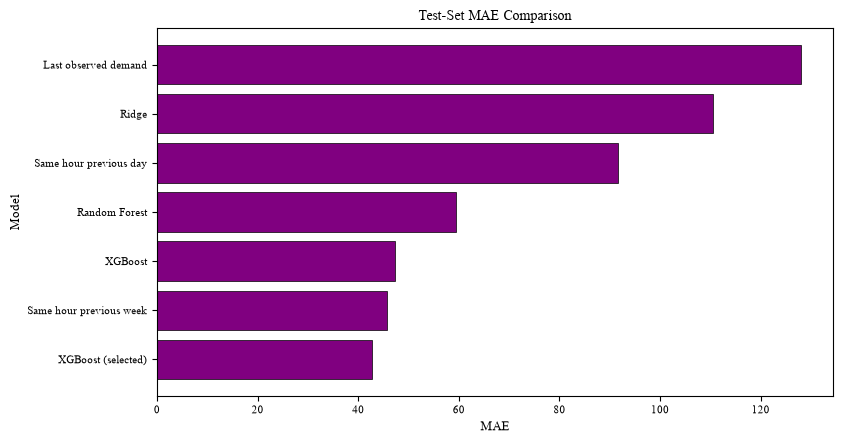

Saved: figures_modeling\model_comparison_mae.png


In [38]:
plot_df = pd.concat([
    baseline_results[["model", "MAE"]],
    pd.DataFrame([
        {"model": "Ridge", "MAE": metrics(test_e4[TARGET], ridge_test)["MAE"]},
        {"model": "Random Forest", "MAE": metrics(test_e4[TARGET], rf_test)["MAE"]},
        {"model": "XGBoost", "MAE": metrics(test_e4[TARGET], xgb_test)["MAE"]},
        {"model": "XGBoost (selected)", "MAE": final_metrics.iloc[0]["MAE"]},
    ])
], ignore_index=True).sort_values("MAE")

fig = plt.figure(figsize=(8.5, 4.5))
plt.barh(plot_df["model"], plot_df["MAE"], color="purple", edgecolor="black", linewidth=0.5)
plt.xlabel("MAE")
plt.ylabel("Model")
plt.title("Test-Set MAE Comparison")
plt.tight_layout()
path = FIGURES_DIR / "model_comparison_mae.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", path)


## 14. Actual vs predicted and error analysis

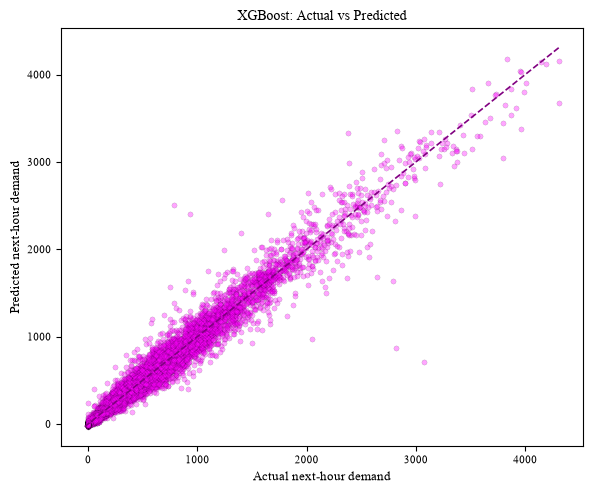

Saved: figures_modeling\xgb_actual_vs_predicted.png


In [18]:
error_test = test_e4[["datetime", "station", "Hour", TARGET]].copy()
error_test["prediction"] = final_pred
error_test["absolute_error"] = np.abs(error_test[TARGET] - error_test["prediction"])
error_test["signed_error"] = error_test["prediction"] - error_test[TARGET]

fig = plt.figure(figsize=(6, 5))
plt.scatter(
    test_e4[TARGET],
    final_pred,
    alpha=0.35,
    s=14,
    color="magenta",
    edgecolor="black",
    linewidth=0.2
)
lims = [
    min(test_e4[TARGET].min(), final_pred.min()),
    max(test_e4[TARGET].max(), final_pred.max()),
]
plt.plot(lims, lims, color="purple", linestyle="--", linewidth=1.2)
plt.xlabel("Actual next-hour demand")
plt.ylabel("Predicted next-hour demand")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
path = FIGURES_DIR / "xgb_actual_vs_predicted.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", path)


,Hour,MAE,Mean_Error
0,0,2.512279,0.785308
1,1,1.765191,0.014810
2,2,2.290609,0.943699
3,3,6.839569,1.625620
4,4,16.926740,-6.654661
5,5,27.794782,6.248128
6,6,55.804320,16.558216
7,7,60.103544,12.727274
8,8,71.524798,36.278955
9,9,77.794176,46.077568


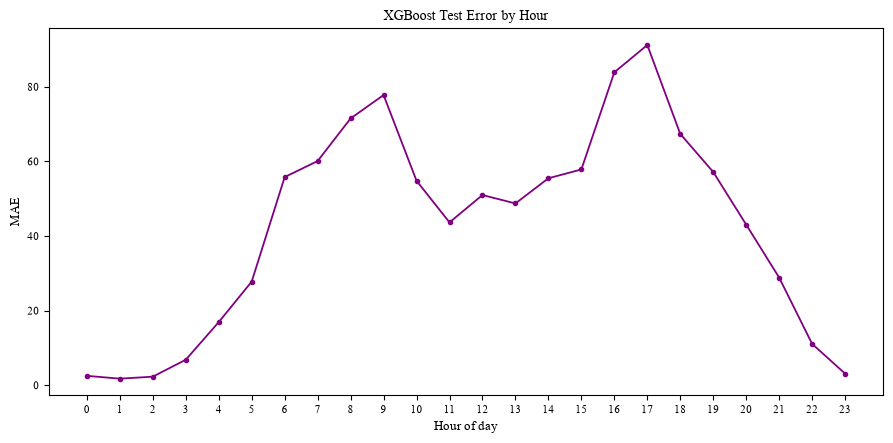

Saved: figures_modeling\xgb_error_by_hour.png


In [39]:
hour_error = (
    error_test.groupby("Hour")
    .agg(MAE=("absolute_error", "mean"),
         Mean_Error=("signed_error", "mean"))
    .reset_index()
)

display(hour_error)

fig = plt.figure(figsize=(9, 4.5))
plt.plot(hour_error["Hour"], hour_error["MAE"],
         color="purple", marker="o", markersize=3, linewidth=1.3)
plt.xlabel("Hour of day")
plt.ylabel("MAE")
plt.title("XGBoost Test Error by Hour")
plt.xticks(range(24))
plt.tight_layout()
path = FIGURES_DIR / "xgb_error_by_hour.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", path)


,MAE,Mean_Error,Mean_Actual,Count
station,,,,
Yeshwantpur,130.441219,24.870539,569.534884,215
"Nadaprabhu Kempegowda Station, Majestic",116.693277,4.170373,1409.502326,215
Benniganahalli,103.699491,-13.803279,1135.316279,215
Mahatma Gandhi Road,91.835364,12.329267,833.097674,215
Krantivira Sangolli Rayanna Railway Station,90.525092,8.862363,501.711628,215
Madavara,88.110878,-0.069670,362.097674,215
Krishnarajapura,84.974375,20.066267,804.706977,215
Baiyappanahalli,76.055667,5.278961,580.000000,215
Chickpete,73.616435,-26.216020,670.111628,215


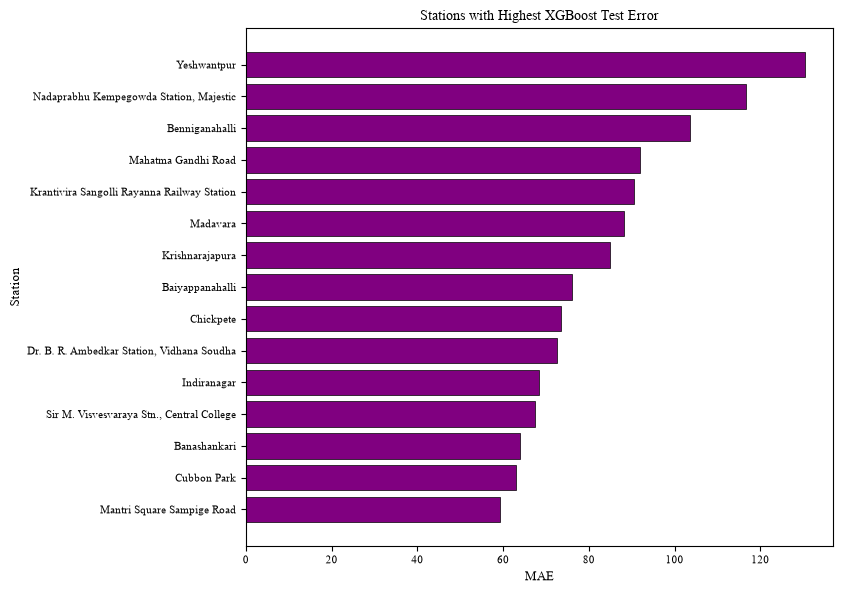

Saved: figures_modeling\xgb_error_by_station.png


In [40]:
station_error = (
    error_test.groupby("station")
    .agg(
        MAE=("absolute_error", "mean"),
        Mean_Error=("signed_error", "mean"),
        Mean_Actual=(TARGET, "mean"),
        Count=(TARGET, "count")
    )
    .sort_values("MAE", ascending=False)
)

display(station_error.head(20))

top = station_error.head(15).sort_values("MAE")

fig = plt.figure(figsize=(8.5, 6))
plt.barh(top.index, top["MAE"], color="purple", edgecolor="black", linewidth=0.5)
plt.xlabel("MAE")
plt.ylabel("Station")
plt.title("Stations with Highest XGBoost Test Error")
plt.tight_layout()
path = FIGURES_DIR / "xgb_error_by_station.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", path)


## 15. Permutation importance

,feature,importance,std
19,demand_current,280.833736,1.037461
1,Hour,90.838061,0.776234
24,demand_lag_168h,59.338233,0.929518
5,hour_cos,36.980576,0.196586
27,rolling_mean_24h,18.754317,0.264674
0,station,14.024400,0.245961
23,demand_lag_24h,13.816314,0.196929
20,demand_lag_1h,10.606681,0.370808
21,demand_lag_2h,9.315810,0.418211
4,hour_sin,8.059460,0.168094


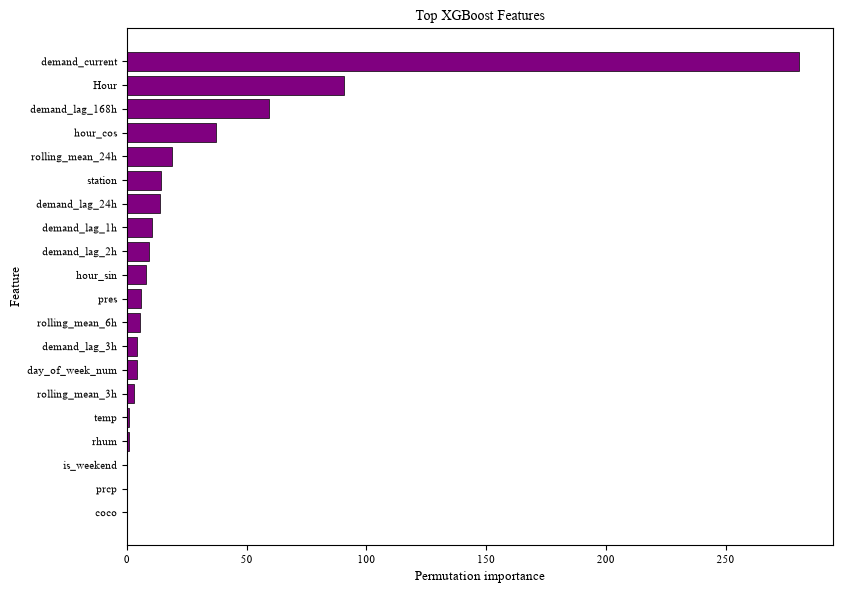

Saved: figures_modeling\xgb_permutation_importance.png


In [41]:
sample = test_e4.sample(
    min(10000, len(test_e4)),
    random_state=42
)

perm = permutation_importance(
    final_xgb,
    sample[features_e4],
    sample[TARGET],
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# permutation_importance() on the complete pipeline
# measures importance of the ORIGINAL input columns.
feature_names = features_e4

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values(
    "importance",
    ascending=False
)

display(importance.head(25))

top_importance = importance.head(20).sort_values("importance")

fig = plt.figure(figsize=(8.5, 6))

plt.barh(
    top_importance["feature"],
    top_importance["importance"],
    color="purple",
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel("Permutation importance")
plt.ylabel("Feature")
plt.title("Top XGBoost Features")

plt.tight_layout()

path = FIGURES_DIR / "xgb_permutation_importance.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", path)

## 16. Save all results

## Interpretation checklist for the paper

The actual results should be used to answer:

1. Do ML models beat simple forecasting baselines?
2. How much does historical demand improve prediction?
3. Does weather add meaningful predictive value?
4. Which stations and hours are hardest to predict?
5. Are peak periods associated with larger errors?
6. Which features receive the highest permutation importance?
7. Does parking information improve accuracy enough to justify reduced station coverage?

Do not claim a model is superior until the held-out test results support that conclusion.


In [43]:
# ============================================================
# Fair E4 vs E5 comparison
# Same stations + same timestamps + same train/validation/test
# ============================================================

E4 = FEATURE_SETS["E4_Full_Temporal"]
E5 = FEATURE_SETS["E5_Full_Plus_Parking"]

print("E4 features:")
print(E4)

print("\nE5 features:")
print(E5)

# ------------------------------------------------------------
# 1. Identify observations where E5 has all required data.
# This defines the exact population that both models will use.
# ------------------------------------------------------------

required_e5 = E5 + [TARGET]

fair_data = df.dropna(
    subset=required_e5
).copy()

print("\nFair-comparison dataset:", fair_data.shape)
print("Stations:", fair_data["station"].nunique())

# ------------------------------------------------------------
# 2. Keep exactly the same observations for E4.
# Since fair_data was defined using E5 completeness,
# E4 is evaluated on precisely the same station-time rows.
# ------------------------------------------------------------

required_e4 = E4 + [TARGET]

fair_data = fair_data.dropna(
    subset=required_e4
).copy()

# ------------------------------------------------------------
# 3. Check station coverage
# ------------------------------------------------------------

eligible_stations = sorted(
    fair_data["station"].unique()
)

print("\nEligible stations:")
print(len(eligible_stations))

# ------------------------------------------------------------
# 4. Check that train/validation/test contain the same
# station population.
# ------------------------------------------------------------

for split in ["train", "validation", "test"]:

    stations = sorted(
        fair_data.loc[
            fair_data["split"] == split,
            "station"
        ].unique()
    )

    print(
        f"{split:12s}: "
        f"{len(stations)} stations, "
        f"{len(fair_data[fair_data['split'] == split]):,} rows"
    )

# ------------------------------------------------------------
# 5. Create identical train/validation/test observations.
# ------------------------------------------------------------

fair_train = fair_data[
    fair_data["split"] == "train"
].copy()

fair_val = fair_data[
    fair_data["split"] == "validation"
].copy()

fair_test = fair_data[
    fair_data["split"] == "test"
].copy()

# ------------------------------------------------------------
# 6. Train E4
# ------------------------------------------------------------

e4_model = Pipeline([
    ("prep", preprocessor(E4)),
    ("model", XGBRegressor(
        **best_params,
        reg_alpha=0,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

e4_model.fit(
    pd.concat([fair_train, fair_val])[E4],
    pd.concat([fair_train, fair_val])[TARGET]
)

e4_pred = e4_model.predict(
    fair_test[E4]
)

e4_metrics = metrics(
    fair_test[TARGET],
    e4_pred
)

# ------------------------------------------------------------
# 7. Train E5
# ------------------------------------------------------------

e5_model = Pipeline([
    ("prep", preprocessor(E5)),
    ("model", XGBRegressor(
        **best_params,
        reg_alpha=0,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

e5_model.fit(
    pd.concat([fair_train, fair_val])[E5],
    pd.concat([fair_train, fair_val])[TARGET]
)

e5_pred = e5_model.predict(
    fair_test[E5]
)

e5_metrics = metrics(
    fair_test[TARGET],
    e5_pred
)

# ------------------------------------------------------------
# 8. Compare
# ------------------------------------------------------------

fair_comparison = pd.DataFrame([
    {
        "Experiment": "E4 - Without Parking",
        "Stations": fair_test["station"].nunique(),
        "Test Samples": len(fair_test),
        **e4_metrics
    },
    {
        "Experiment": "E5 - With Parking",
        "Stations": fair_test["station"].nunique(),
        "Test Samples": len(fair_test),
        **e5_metrics
    }
])

display(fair_comparison)

E4 features:
['station', 'Hour', 'day_of_week_num', 'month_num', 'hour_sin', 'hour_cos', 'is_weekend', 'is_public_holiday', 'is_major_city_event', 'is_working_day_proxy', 'is_day_before_public_holiday', 'is_day_after_public_holiday', 'temp', 'rhum', 'prcp', 'wspd', 'pres', 'cldc', 'coco', 'demand_current', 'demand_lag_1h', 'demand_lag_2h', 'demand_lag_3h', 'demand_lag_24h', 'demand_lag_168h', 'rolling_mean_3h', 'rolling_mean_6h', 'rolling_mean_24h']

E5 features:
['station', 'Hour', 'day_of_week_num', 'month_num', 'hour_sin', 'hour_cos', 'is_weekend', 'is_public_holiday', 'is_major_city_event', 'is_working_day_proxy', 'is_day_before_public_holiday', 'is_day_after_public_holiday', 'temp', 'rhum', 'prcp', 'wspd', 'pres', 'cldc', 'coco', 'demand_current', 'demand_lag_1h', 'demand_lag_2h', 'demand_lag_3h', 'demand_lag_24h', 'demand_lag_168h', 'rolling_mean_3h', 'rolling_mean_6h', 'rolling_mean_24h', '2_WHEELER', '4_WHEELER']

Fair-comparison dataset: (28700, 40)
Stations: 50

Eligible stat

,Experiment,Stations,Test Samples,MAE,RMSE,R2,sMAPE_%,WAPE_%
0,E4 - Without Parking,50,10750,33.923406,67.153959,0.972966,52.647184,10.476564
1,E5 - With Parking,50,10750,33.673869,66.757869,0.973284,52.421679,10.399499


In [44]:
# Percentage change from E4 to E5
mae_change = (
    (e4_metrics["MAE"] - e5_metrics["MAE"])
    / e4_metrics["MAE"]
) * 100

rmse_change = (
    (e4_metrics["RMSE"] - e5_metrics["RMSE"])
    / e4_metrics["RMSE"]
) * 100

wape_change = (
    (e4_metrics["WAPE_%"] - e5_metrics["WAPE_%"])
    / e4_metrics["WAPE_%"]
) * 100

r2_change = e5_metrics.get("R2", np.nan) - e4_metrics.get("R2", np.nan)

print(f"MAE change:  {mae_change:+.2f}%")
print(f"RMSE change: {rmse_change:+.2f}%")
print(f"WAPE change: {wape_change:+.2f}%")
print(f"R² change:   {r2_change:+.4f}")

MAE change:  +0.74%
RMSE change: +0.59%
WAPE change: +0.74%
R² change:   +0.0003
